# Stock Forecasting: Modeling and Temporal Validation

## Prediction contract

At the end of trading day $t$, the model uses completed price and volume
information available through that session to predict:

1. The closing price on the next trading day, $t+1$.
2. The close-to-close return from day $t$ to day $t+1$.

The primary statistical target is the next-day return:

$$
r_{i,t+1}
=
\frac{\mathrm{Close}_{i,t+1}}
{\mathrm{Close}_{i,t}}
- 1
$$

where:

- $i$ represents the stock ticker.
- $t$ represents the current trading day.
- $r_{i,t+1}$ represents the stock's return on the next trading day.

The predicted return is converted into a next-day closing-price forecast using:

$$
\widehat{\mathrm{Close}}_{i,t+1}
=
\mathrm{Close}_{i,t}
\left(1+\widehat{r}_{i,t+1}\right)
$$

All dataset splits are chronological. A random train-test split is not used
because it could allow future market observations to influence model
development and produce an unrealistically optimistic evaluation.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().parent
PRICE_PATH = PROJECT_ROOT / "data" / "raw" / "price.csv"
NEWS_PATH = PROJECT_ROOT / "data" / "raw" / "news.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
prices = (
    pd.read_csv(PRICE_PATH, parse_dates=["date"])
    .assign(
        ticker=lambda df: df["ticker"].str.strip().str.upper()
    )
    .drop_duplicates()
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

news = (
    pd.read_csv(NEWS_PATH, parse_dates=["datetime"])
    .assign(
        ticker=lambda df: df["ticker"].str.strip().str.upper(),
        headline=lambda df: df["headline"].str.strip(),
        summary=lambda df: df["summary"].fillna("").str.strip(),
    )
    .drop_duplicates()
    .sort_values(["ticker", "datetime"])
    .reset_index(drop=True)
)

print(f"Prices: {prices.shape}")
print(f"News:   {news.shape}")

Prices: (1687, 7)
News:   (4439, 4)


Construct the targets

In [5]:
modeling_data = prices.copy()

grouped_close = modeling_data.groupby("ticker")["close"]

modeling_data["current_return"] = grouped_close.pct_change(
    fill_method=None
)

modeling_data["next_close"] = grouped_close.shift(-1)

modeling_data["next_return"] = (
    modeling_data["next_close"] / modeling_data["close"] - 1
)

modeling_data["target_direction"] = (
    modeling_data["next_return"] > 0
).astype(int)

target_check = modeling_data[
    [
        "date",
        "ticker",
        "close",
        "current_return",
        "next_close",
        "next_return",
        "target_direction",
    ]
].head(10)

display(target_check)

,date,ticker,close,current_return,next_close,next_return,target_direction
0,2023-11-13,AAPL,184.800003,NaN,187.440002,0.014286,1
1,2023-11-14,AAPL,187.440002,0.014286,188.009995,0.003041,1
2,2023-11-15,AAPL,188.009995,0.003041,189.710007,0.009042,1
3,2023-11-16,AAPL,189.710007,0.009042,189.690002,-0.000105,0
4,2023-11-17,AAPL,189.690002,-0.000105,191.449997,0.009278,1
5,2023-11-20,AAPL,191.449997,0.009278,190.639999,-0.004231,0
6,2023-11-21,AAPL,190.639999,-0.004231,191.309998,0.003514,1
7,2023-11-22,AAPL,191.309998,0.003514,189.970001,-0.007004,0
8,2023-11-24,AAPL,189.970001,-0.007004,189.789993,-0.000948,0
9,2023-11-27,AAPL,189.789993,-0.000948,190.399994,0.003214,1


In [6]:
print(
    "Rows without next-day targets:",
    modeling_data["next_return"].isna().sum(),
)

display(
    modeling_data[
        modeling_data["next_return"].isna()
    ][["date", "ticker", "close", "next_close"]]
)

Rows without next-day targets: 7


,date,ticker,close,next_close
240,2024-10-28,AAPL,233.399994,NaN
481,2024-10-28,AMZN,188.389999,NaN
722,2024-10-28,GOOGL,166.720001,NaN
963,2024-10-28,META,578.159973,NaN
1204,2024-10-28,MSFT,426.589996,NaN
1445,2024-10-28,NVDA,140.520004,NaN
1686,2024-10-28,TSLA,262.510010,NaN


Remove records without targets

In [7]:
modeling_data = (
    modeling_data
    .dropna(subset=["next_close", "next_return"])
    .reset_index(drop=True)
)

print(f"Modeling rows with targets: {len(modeling_data):,}")

Modeling rows with targets: 1,680


train-val-test split

In [8]:
unique_dates = np.array(
    sorted(modeling_data["date"].unique())
)

train_end_index = int(len(unique_dates) * 0.70)
validation_end_index = int(len(unique_dates) * 0.85)

train_dates = unique_dates[:train_end_index]
validation_dates = unique_dates[
    train_end_index:validation_end_index
]
test_dates = unique_dates[validation_end_index:]

train = modeling_data[
    modeling_data["date"].isin(train_dates)
].copy()

validation = modeling_data[
    modeling_data["date"].isin(validation_dates)
].copy()

test = modeling_data[
    modeling_data["date"].isin(test_dates)
].copy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train), len(validation), len(test)],
        "unique_dates": [
            train["date"].nunique(),
            validation["date"].nunique(),
            test["date"].nunique(),
        ],
        "first_date": [
            train["date"].min(),
            validation["date"].min(),
            test["date"].min(),
        ],
        "last_date": [
            train["date"].max(),
            validation["date"].max(),
            test["date"].max(),
        ],
    }
)

display(split_summary)

,split,rows,unique_dates,first_date,last_date
0,train,1176,168,2023-11-13,2024-07-16
1,validation,252,36,2024-07-17,2024-09-05
2,test,252,36,2024-09-06,2024-10-25


In [9]:
assert train["date"].max() < validation["date"].min()
assert validation["date"].max() < test["date"].min()

assert set(train["date"]).isdisjoint(validation["date"])
assert set(train["date"]).isdisjoint(test["date"])
assert set(validation["date"]).isdisjoint(test["date"])

print("Chronological split validation passed.")

Chronological split validation passed.


Naive random-walk baseline:
Assumes tomorrow's closing price equals today's
$$
\widehat{\mathrm{Close}}_{t+1}
=
\mathrm{Close}_{t}
$$

In [10]:
def regression_metrics(
    actual_price: pd.Series,
    predicted_price: pd.Series,
    actual_return: pd.Series,
    predicted_return: pd.Series,
) -> dict:
    return {
        "price_mae": mean_absolute_error(
            actual_price,
            predicted_price,
        ),
        "price_rmse": np.sqrt(
            mean_squared_error(
                actual_price,
                predicted_price,
            )
        ),
        "return_mae": mean_absolute_error(
            actual_return,
            predicted_return,
        ),
        "return_rmse": np.sqrt(
            mean_squared_error(
                actual_return,
                predicted_return,
            )
        ),
    }

In [11]:
def evaluate_random_walk(
    data: pd.DataFrame,
    split_name: str,
) -> dict:
    predicted_price = data["close"]
    predicted_return = np.zeros(len(data))

    metrics = regression_metrics(
        actual_price=data["next_close"],
        predicted_price=predicted_price,
        actual_return=data["next_return"],
        predicted_return=predicted_return,
    )

    return {
        "model": "Random walk",
        "split": split_name,
        **metrics,
    }


baseline_results = pd.DataFrame(
    [
        evaluate_random_walk(train, "train"),
        evaluate_random_walk(validation, "validation"),
        evaluate_random_walk(test, "test"),
    ]
)

display(
    baseline_results.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
        }
    )
)

,model,split,price_mae,price_rmse,return_mae,return_rmse
0,Random walk,train,$3.274,$5.526,1.497%,2.253%
1,Random walk,validation,$4.563,$6.574,1.999%,2.871%
2,Random walk,test,$3.303,$5.463,1.340%,2.270%


In [12]:
ticker_baseline_results = []

for ticker, group in test.groupby("ticker"):
    metrics = regression_metrics(
        actual_price=group["next_close"],
        predicted_price=group["close"],
        actual_return=group["next_return"],
        predicted_return=np.zeros(len(group)),
    )

    ticker_baseline_results.append(
        {
            "ticker": ticker,
            **metrics,
        }
    )

ticker_baseline_results = pd.DataFrame(
    ticker_baseline_results
).sort_values("return_rmse", ascending=False)

display(
    ticker_baseline_results.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
        }
    )
)

,ticker,price_mae,price_rmse,return_mae,return_rmse
6,TSLA,$6.101,$10.306,2.613%,4.618%
5,NVDA,$2.525,$3.233,2.057%,2.670%
1,AMZN,$1.991,$2.487,1.078%,1.354%
0,AAPL,$2.218,$3.057,0.978%,1.352%
3,META,$5.531,$7.462,0.986%,1.338%
2,GOOGL,$1.410,$1.717,0.877%,1.073%
4,MSFT,$3.348,$4.254,0.794%,1.011%


### Random-walk baseline results

The random-walk baseline assumes that the next closing price will equal the
current closing price, corresponding to a predicted return of zero.

On the held-out test period, this baseline achieved a price MAE of approximately
$3.30 and a return MAE of 1.34%. These scores establish the minimum benchmark
that more sophisticated models must improve upon.

Performance differs across the three chronological periods. The validation
period has higher errors than both the training and test periods, suggesting
that it represents a comparatively difficult or volatile market regime. This
variation demonstrates why evaluation across multiple chronological periods is
more informative than relying on one random split.

Ticker-level results are consistent with the exploratory volatility analysis.
Tesla is the most difficult stock to forecast, with a test return RMSE of 4.62%,
followed by NVIDIA at 2.67%. Microsoft and Google have the lowest return RMSE
values, reflecting their comparatively narrower daily-return distributions.

Price errors are influenced by the scale of each stock's price and should not
be compared across tickers in isolation. Return-based metrics provide a more
comparable assessment of forecasting difficulty.

## Price and volume feature engineering

Features are calculated using information available through the end of trading
day \(t\). The target remains the return on trading day \(t+1\).

Rolling calculations are performed independently for each ticker to prevent
information from crossing company boundaries.

In [13]:
features = prices.sort_values(["ticker", "date"]).copy()

close_group = features.groupby("ticker")["close"]
volume_group = features.groupby("ticker")["volume"]

# Returns and momentum
features["return_1d"] = close_group.pct_change(fill_method=None)

for window in [2, 5, 10, 20]:
    features[f"return_{window}d"] = (
        features["close"]
        / close_group.shift(window)
        - 1
    )

# Intraday behavior
features["intraday_return"] = (
    features["close"] / features["open"] - 1
)

features["intraday_range"] = (
    features["high"] - features["low"]
) / features["open"]

features["close_position"] = (
    features["close"] - features["low"]
) / (features["high"] - features["low"]).replace(0, np.nan)

# Rolling statistics
for window in [5, 10, 20]:
    features[f"mean_return_{window}d"] = (
        features
        .groupby("ticker")["return_1d"]
        .transform(
            lambda values: values.rolling(window).mean()
        )
    )

    features[f"volatility_{window}d"] = (
        features
        .groupby("ticker")["return_1d"]
        .transform(
            lambda values: values.rolling(window).std()
        )
    )

    moving_average = (
        features
        .groupby("ticker")["close"]
        .transform(
            lambda values: values.rolling(window).mean()
        )
    )

    features[f"close_to_sma_{window}d"] = (
        features["close"] / moving_average - 1
    )

# Volume features
features["volume_change_1d"] = (
    volume_group.pct_change(fill_method=None)
)

features["volume_mean_20d"] = (
    features
    .groupby("ticker")["volume"]
    .transform(
        lambda values: values.rolling(20).mean()
    )
)

features["relative_volume_20d"] = (
    features["volume"] / features["volume_mean_20d"]
)

# Cross-sectional market context known at the end of day t
features["market_return_1d"] = (
    features
    .groupby("date")["return_1d"]
    .transform("mean")
)

features["relative_return_1d"] = (
    features["return_1d"]
    - features["market_return_1d"]
)

# Calendar variables
features["day_of_week"] = features["date"].dt.dayofweek
features["month"] = features["date"].dt.month

# Next-trading-day targets
features["next_close"] = close_group.shift(-1)

features["next_return"] = (
    features["next_close"] / features["close"] - 1
)

features.replace([np.inf, -np.inf], np.nan, inplace=True)

,date,ticker,open,high,low,close,volume,return_1d,return_2d,return_5d,return_10d,return_20d,intraday_return,intraday_range,close_position,mean_return_5d,volatility_5d,close_to_sma_5d,mean_return_10d,volatility_10d,close_to_sma_10d,mean_return_20d,volatility_20d,close_to_sma_20d,volume_change_1d,volume_mean_20d,relative_volume_20d,market_return_1d,relative_return_1d,day_of_week,month,next_close,next_return
0,2023-11-13,AAPL,185.820007,186.029999,184.210007,184.800003,43627500,NaN,NaN,NaN,NaN,NaN,-0.005489,0.009794,0.324175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,11,187.440002,0.014286
1,2023-11-14,AAPL,187.699997,188.110001,186.300003,187.440002,60108400,0.014286,NaN,NaN,NaN,NaN,-0.001385,0.009643,0.629835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.377764,NaN,NaN,0.023193,-0.008907,1,11,188.009995,0.003041
2,2023-11-15,AAPL,187.850006,189.500000,187.779999,188.009995,53790500,0.003041,0.017370,NaN,NaN,NaN,0.000852,0.009156,0.133718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.105108,NaN,NaN,-0.001747,0.004788,2,11,189.710007,0.009042
3,2023-11-16,AAPL,189.570007,190.960007,188.649994,189.710007,54412900,0.009042,0.012111,NaN,NaN,NaN,0.000739,0.012186,0.458877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011571,NaN,NaN,0.002810,0.006232,3,11,189.690002,-0.000105
4,2023-11-17,AAPL,190.250000,190.380005,188.570007,189.690002,50922700,-0.000105,0.008936,NaN,NaN,NaN,-0.002943,0.009514,0.618783,NaN,NaN,0.009365,NaN,NaN,NaN,NaN,NaN,NaN,-0.064143,NaN,NaN,-0.001483,0.001377,4,11,191.449997,0.009278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1682,2024-10-22,TSLA,217.309998,218.220001,215.259995,217.970001,43268700,-0.004021,-0.012370,-0.007287,-0.108507,-0.142762,0.003037,0.013621,0.915541,-0.001447,0.006019,-0.008993,-0.011052,0.027845,-0.025218,-0.007321,0.026806,-0.082720,-0.085789,"71,944,555.000000",0.601417,0.005019,-0.009040,1,10,213.649994,-0.019819
1683,2024-10-23,TSLA,217.130005,218.720001,212.110001,213.649994,80938900,-0.019819,-0.023761,-0.034699,-0.113669,-0.168742,-0.016027,0.030443,0.232979,-0.007014,0.007713,-0.021803,-0.011622,0.027973,-0.032685,-0.008852,0.026590,-0.092620,0.870611,"72,739,785.000000",1.112718,-0.021198,0.001379,2,10,260.480011,0.219190
1684,2024-10-24,TSLA,244.679993,262.119995,242.649994,260.480011,204491900,0.219190,0.195027,0.179230,0.090924,0.024624,0.064574,0.079573,0.915769,0.037221,0.101977,0.150886,0.011243,0.078234,0.167862,0.002652,0.057485,0.104801,1.526497,"79,607,270.000000",2.568759,0.034385,0.184806,3,10,269.190002,0.033438
1685,2024-10-25,TSLA,256.010010,269.489990,255.320007,269.190002,161611900,0.033438,0.259958,0.219710,0.235950,0.033518,0.051482,0.055349,0.978829,0.044081,0.099907,0.140500,0.023369,0.070152,0.179732,0.003096,0.057697,0.139634,-0.209690,"84,138,460.000000",1.920785,0.012324,0.021114,4,10,262.510010,-0.024815


Select Modeling Columns

In [14]:
numeric_features = [
    "return_1d",
    "return_2d",
    "return_5d",
    "return_10d",
    "return_20d",
    "intraday_return",
    "intraday_range",
    "close_position",
    "mean_return_5d",
    "mean_return_10d",
    "mean_return_20d",
    "volatility_5d",
    "volatility_10d",
    "volatility_20d",
    "close_to_sma_5d",
    "close_to_sma_10d",
    "close_to_sma_20d",
    "volume_change_1d",
    "relative_volume_20d",
    "market_return_1d",
    "relative_return_1d",
    "day_of_week",
    "month",
]

categorical_features = ["ticker"]

required_columns = (
    numeric_features
    + categorical_features
    + ["date", "close", "next_close", "next_return"]
)

model_data = (
    features[required_columns]
    .dropna()
    .sort_values(["date", "ticker"])
    .reset_index(drop=True)
)

print(f"Rows before feature filtering: {len(features):,}")
print(f"Complete modeling rows: {len(model_data):,}")
print(f"Unique modeling dates: {model_data['date'].nunique()}")

Rows before feature filtering: 1,687
Complete modeling rows: 1,540
Unique modeling dates: 220


Train-Val-Test Split

In [15]:
model_dates = np.array(sorted(model_data["date"].unique()))

train_end = int(len(model_dates) * 0.70)
validation_end = int(len(model_dates) * 0.85)

train_dates = model_dates[:train_end]
validation_dates = model_dates[train_end:validation_end]
test_dates = model_dates[validation_end:]

train = model_data[model_data["date"].isin(train_dates)].copy()
validation = model_data[
    model_data["date"].isin(validation_dates)
].copy()
test = model_data[model_data["date"].isin(test_dates)].copy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train), len(validation), len(test)],
        "dates": [
            train["date"].nunique(),
            validation["date"].nunique(),
            test["date"].nunique(),
        ],
        "start": [
            train["date"].min(),
            validation["date"].min(),
            test["date"].min(),
        ],
        "end": [
            train["date"].max(),
            validation["date"].max(),
            test["date"].max(),
        ],
    }
)

display(split_summary)

,split,rows,dates,start,end
0,train,1078,154,2023-12-12,2024-07-24
1,validation,231,33,2024-07-25,2024-09-10
2,test,231,33,2024-09-11,2024-10-25


Train Ridge Regression Model

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "ticker",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ]
)

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0)),
    ]
)

X_train = train[numeric_features + categorical_features]
y_train = train["next_return"]

ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['return_1d','return_2d','return_5d',...,'day_of_week','month','ticker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ticker', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

Evaluate Ridge Model and Compare with Baseline

In [18]:
def evaluate_return_model(
    model,
    data: pd.DataFrame,
    model_name: str,
    split_name: str,
) -> dict:
    X = data[numeric_features + categorical_features]

    predicted_return = model.predict(X)
    predicted_price = data["close"] * (1 + predicted_return)

    actual_direction = data["next_return"] > 0
    predicted_direction = predicted_return > 0

    return {
        "model": model_name,
        "split": split_name,
        "price_mae": mean_absolute_error(
            data["next_close"],
            predicted_price,
        ),
        "price_rmse": np.sqrt(
            mean_squared_error(
                data["next_close"],
                predicted_price,
            )
        ),
        "return_mae": mean_absolute_error(
            data["next_return"],
            predicted_return,
        ),
        "return_rmse": np.sqrt(
            mean_squared_error(
                data["next_return"],
                predicted_return,
            )
        ),
        "direction_accuracy": (
            actual_direction == predicted_direction
        ).mean(),
    }

In [19]:
comparison_results = []

for split_name, split_data in [
    ("train", train),
    ("validation", validation),
    ("test", test),
]:
    # Random-walk baseline on the exact same rows
    baseline = regression_metrics(
        actual_price=split_data["next_close"],
        predicted_price=split_data["close"],
        actual_return=split_data["next_return"],
        predicted_return=np.zeros(len(split_data)),
    )

    comparison_results.append(
        {
            "model": "Random walk",
            "split": split_name,
            **baseline,
            "direction_accuracy": np.nan,
        }
    )

    comparison_results.append(
        evaluate_return_model(
            ridge_model,
            split_data,
            "Ridge",
            split_name,
        )
    )

comparison_results = pd.DataFrame(comparison_results)

display(
    comparison_results.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,model,split,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,Random walk,train,$3.468,$5.890,1.557%,2.370%,nan%
1,Ridge,train,$3.432,$5.839,1.527%,2.314%,57.70%
2,Random walk,validation,$4.310,$5.982,1.951%,2.784%,nan%
3,Ridge,validation,$4.526,$6.251,2.052%,2.948%,43.29%
4,Random walk,test,$3.233,$5.498,1.285%,2.232%,nan%
5,Ridge,test,$3.238,$5.542,1.300%,2.275%,48.92%


### Ridge regression results

Ridge regression produces a small improvement over the random-walk baseline on
the training period but fails to maintain that improvement on unseen dates.

On the validation period, Ridge increases return MAE from 1.95% to 2.05% and
reduces directional accuracy to 43.29%. Test performance is closer to the
baseline, but Ridge remains slightly worse in both price and return metrics.
Its test directional accuracy of 48.92% is also below 50%.

The difference between training and unseen-period performance indicates that
the linear relationships identified in historical returns, volatility, volume,
and market features are not stable across the full sample. This may reflect
nonlinear behavior, changing market regimes, or a low signal-to-noise ratio in
next-day returns.

The result reinforces the importance of comparing every model against a simple
random-walk benchmark. A more complex model should only be preferred if it
produces consistent improvements on chronological validation data.

Try Tree models-> XGBoost

In [20]:
from xgboost import XGBRegressor

In [21]:
X_train_processed = preprocessor.fit_transform(
    train[numeric_features + categorical_features]
)

X_validation_processed = preprocessor.transform(
    validation[numeric_features + categorical_features]
)

X_test_processed = preprocessor.transform(
    test[numeric_features + categorical_features]
)

y_train = train["next_return"]
y_validation = validation["next_return"]
y_test = test["next_return"]

print("Training matrix:", X_train_processed.shape)
print("Validation matrix:", X_validation_processed.shape)
print("Test matrix:", X_test_processed.shape)

Training matrix: (1078, 30)
Validation matrix: (231, 30)
Test matrix: (231, 30)


In [22]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=10,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.01,
    reg_lambda=5.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=40,
)

xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[
        (X_validation_processed, y_validation)
    ],
    verbose=False,
)

print("Best iteration:", xgb_model.best_iteration)

Best iteration: 2


Evaluate XGBoost

In [23]:
def evaluate_processed_model(
    model,
    X,
    data: pd.DataFrame,
    model_name: str,
    split_name: str,
) -> dict:
    predicted_return = model.predict(X)
    predicted_price = data["close"] * (1 + predicted_return)

    return {
        "model": model_name,
        "split": split_name,
        "price_mae": mean_absolute_error(
            data["next_close"],
            predicted_price,
        ),
        "price_rmse": np.sqrt(
            mean_squared_error(
                data["next_close"],
                predicted_price,
            )
        ),
        "return_mae": mean_absolute_error(
            data["next_return"],
            predicted_return,
        ),
        "return_rmse": np.sqrt(
            mean_squared_error(
                data["next_return"],
                predicted_return,
            )
        ),
        "direction_accuracy": (
            (data["next_return"].to_numpy() > 0)
            == (predicted_return > 0)
        ).mean(),
    }

In [24]:
xgb_results = pd.DataFrame(
    [
        evaluate_processed_model(
            xgb_model,
            X_train_processed,
            train,
            "XGBoost",
            "train",
        ),
        evaluate_processed_model(
            xgb_model,
            X_validation_processed,
            validation,
            "XGBoost",
            "validation",
        ),
        evaluate_processed_model(
            xgb_model,
            X_test_processed,
            test,
            "XGBoost",
            "test",
        ),
    ]
)

all_model_results = pd.concat(
    [
        comparison_results,
        xgb_results,
    ],
    ignore_index=True,
)

display(
    all_model_results.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,model,split,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,Random walk,train,$3.468,$5.890,1.557%,2.370%,nan%
1,Ridge,train,$3.432,$5.839,1.527%,2.314%,57.70%
2,Random walk,validation,$4.310,$5.982,1.951%,2.784%,nan%
3,Ridge,validation,$4.526,$6.251,2.052%,2.948%,43.29%
4,Random walk,test,$3.233,$5.498,1.285%,2.232%,nan%
5,Ridge,test,$3.238,$5.542,1.300%,2.275%,48.92%
6,XGBoost,train,$3.455,$5.884,1.547%,2.357%,54.17%
7,XGBoost,validation,$4.287,$5.968,1.937%,2.783%,54.98%
8,XGBoost,test,$3.199,$5.453,1.266%,2.215%,58.01%


In [25]:
training_positive_rate = (
    train["next_return"] > 0
).mean()

majority_prediction = training_positive_rate >= 0.5

direction_baselines = []

for split_name, split_data in [
    ("train", train),
    ("validation", validation),
    ("test", test),
]:
    actual_direction = split_data["next_return"] > 0

    majority_accuracy = (
        actual_direction == majority_prediction
    ).mean()

    momentum_accuracy = (
        actual_direction
        == (split_data["return_1d"] > 0)
    ).mean()

    direction_baselines.extend(
        [
            {
                "model": "Training-majority direction",
                "split": split_name,
                "direction_accuracy": majority_accuracy,
            },
            {
                "model": "Previous-day direction",
                "split": split_name,
                "direction_accuracy": momentum_accuracy,
            },
        ]
    )

direction_baselines = pd.DataFrame(direction_baselines)

display(
    direction_baselines.style.format(
        {"direction_accuracy": "{:.2%}"}
    )
)

,model,split,direction_accuracy
0,Training-majority direction,train,54.17%
1,Previous-day direction,train,51.95%
2,Training-majority direction,validation,54.98%
3,Previous-day direction,validation,42.86%
4,Training-majority direction,test,58.01%
5,Previous-day direction,test,51.08%


In [26]:
for split_name, X_processed in [
    ("train", X_train_processed),
    ("validation", X_validation_processed),
    ("test", X_test_processed),
]:
    predictions = xgb_model.predict(X_processed)

    print(
        split_name,
        {
            "minimum_prediction": predictions.min(),
            "maximum_prediction": predictions.max(),
            "mean_prediction": predictions.mean(),
            "predicted_positive_share": (
                predictions > 0
            ).mean(),
        },
    )

train {'minimum_prediction': np.float32(0.001671503), 'maximum_prediction': np.float32(0.0034781836), 'mean_prediction': np.float32(0.0018658001), 'predicted_positive_share': np.float64(1.0)}
validation {'minimum_prediction': np.float32(0.001693827), 'maximum_prediction': np.float32(0.0033132355), 'mean_prediction': np.float32(0.0019102592), 'predicted_positive_share': np.float64(1.0)}
test {'minimum_prediction': np.float32(0.001671503), 'maximum_prediction': np.float32(0.0033132355), 'mean_prediction': np.float32(0.0018325817), 'predicted_positive_share': np.float64(1.0)}


In [27]:
global_mean_return = train["next_return"].mean()

ticker_mean_returns = (
    train
    .groupby("ticker")["next_return"]
    .mean()
    .to_dict()
)

print(f"Training global mean return: {global_mean_return:.4%}")
display(
    pd.Series(
        ticker_mean_returns,
        name="training_mean_return",
    ).to_frame().style.format("{:.4%}")
)

Training global mean return: 0.1892%


,training_mean_return
AAPL,0.0832%
AMZN,0.1407%
GOOGL,0.1667%
META,0.2304%
MSFT,0.0797%
NVDA,0.6089%
TSLA,0.0151%


In [28]:
def evaluate_constant_predictions(
    data: pd.DataFrame,
    predicted_return: np.ndarray,
    model_name: str,
    split_name: str,
) -> dict:
    predicted_price = (
        data["close"].to_numpy()
        * (1 + predicted_return)
    )

    return {
        "model": model_name,
        "split": split_name,
        "price_mae": mean_absolute_error(
            data["next_close"],
            predicted_price,
        ),
        "price_rmse": np.sqrt(
            mean_squared_error(
                data["next_close"],
                predicted_price,
            )
        ),
        "return_mae": mean_absolute_error(
            data["next_return"],
            predicted_return,
        ),
        "return_rmse": np.sqrt(
            mean_squared_error(
                data["next_return"],
                predicted_return,
            )
        ),
        "direction_accuracy": (
            (data["next_return"].to_numpy() > 0)
            == (predicted_return > 0)
        ).mean(),
    }

In [29]:
constant_baseline_results = []

for split_name, split_data in [
    ("train", train),
    ("validation", validation),
    ("test", test),
]:
    global_predictions = np.full(
        len(split_data),
        global_mean_return,
    )

    ticker_predictions = (
        split_data["ticker"]
        .map(ticker_mean_returns)
        .to_numpy()
    )

    constant_baseline_results.extend(
        [
            evaluate_constant_predictions(
                split_data,
                global_predictions,
                "Global historical mean",
                split_name,
            ),
            evaluate_constant_predictions(
                split_data,
                ticker_predictions,
                "Ticker historical mean",
                split_name,
            ),
        ]
    )

constant_baseline_results = pd.DataFrame(
    constant_baseline_results
)

expanded_results = pd.concat(
    [
        comparison_results,
        xgb_results,
        constant_baseline_results,
    ],
    ignore_index=True,
)

display(
    expanded_results.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,model,split,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,Random walk,train,$3.468,$5.890,1.557%,2.370%,nan%
1,Ridge,train,$3.432,$5.839,1.527%,2.314%,57.70%
2,Random walk,validation,$4.310,$5.982,1.951%,2.784%,nan%
3,Ridge,validation,$4.526,$6.251,2.052%,2.948%,43.29%
4,Random walk,test,$3.233,$5.498,1.285%,2.232%,nan%
5,Ridge,test,$3.238,$5.542,1.300%,2.275%,48.92%
6,XGBoost,train,$3.455,$5.884,1.547%,2.357%,54.17%
7,XGBoost,validation,$4.287,$5.968,1.937%,2.783%,54.98%
8,XGBoost,test,$3.199,$5.453,1.266%,2.215%,58.01%
9,Global historical mean,train,$3.462,$5.895,1.551%,2.363%,54.17%


### XGBoost results

XGBoost produces slightly lower price and return errors than the random-walk
baseline on both validation and test data. However, its directional accuracy
exactly matches the training-majority baseline in every split.

This result suggests that the model may predict a positive return for nearly
every observation rather than distinguishing between positive and negative
days. Its apparent directional performance therefore cannot be interpreted as
evidence of successful market-direction forecasting.

The small error improvement may instead come from estimating the sample's
positive average return more effectively than the zero-return random-walk
baseline. Constant global and ticker-specific historical-mean forecasts are
introduced to determine whether XGBoost provides incremental predictive value
beyond this simple drift estimate.

### Comparison with historical-drift baselines

The constant-return baselines demonstrate that XGBoost provides almost no
incremental improvement beyond estimating positive historical drift.

On validation and test data, the global historical-mean forecast produces
nearly identical errors to XGBoost. The ticker-specific historical-mean model
slightly outperforms XGBoost on the test period, achieving a return MAE of
1.261% compared with 1.266%.

All three approaches achieve identical directional accuracy because they
predict positive returns for nearly every observation. Their directional
accuracy therefore represents the proportion of positive observations in each
split rather than successful discrimination between positive and negative
market movements.

These results indicate that the structured price and volume features have not
yet provided stable incremental signal beyond historical drift. The news
ablation will test whether textual market information improves this result.

-------------------------------------------------------------------------

## Financial-news sentiment

Financial news contains information that cannot be represented directly by
historical prices and volume. A pretrained FinBERT model is used to extract
positive, neutral, and negative sentiment probabilities from each article.

FinBERT is not used as the stock-forecasting model. It is used only to transform
unstructured text into numeric features. The forecasting models themselves are
trained and evaluated on the provided assignment data.

Article-level net sentiment is defined as:

$$
Sentiment =
P(\mathrm{positive}) - P(\mathrm{negative})
$$

Prepare the text

In [29]:
from tqdm.auto import tqdm
import torch

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

SENTIMENT_CACHE_PATH = (
    PROCESSED_DATA_DIR
    / "news_with_finbert_sentiment.csv"
)

news_for_sentiment = news.copy()

news_for_sentiment["text"] = (
    news_for_sentiment["headline"].fillna("")
    + ". "
    + news_for_sentiment["summary"].fillna("")
).str.strip()

print(f"Articles to score: {len(news_for_sentiment):,}")
print(f"Cache exists: {SENTIMENT_CACHE_PATH.exists()}")

/Users/camilo/stock-news-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Articles to score: 4,439
Cache exists: False


Load FinBERT and test it works

In [1]:
import torch

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    pipeline,
)

MODEL_NAME = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
)

finbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
)

inference_device = (
    "mps"
    if torch.backends.mps.is_available()
    else -1
)

print(f"Inference device: {inference_device}")

finbert = pipeline(
    task="text-classification",
    model=finbert_model,
    tokenizer=tokenizer,
    top_k=None,
    device=inference_device,
)

print("FinBERT loaded successfully.")

/Users/camilo/stock-news-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 47216.75it/s]


Inference device: mps
FinBERT loaded successfully.


In [2]:
test_sentiment = finbert(
    [
        "The company reported record revenue and increased guidance.",
        "The company missed earnings expectations and announced layoffs.",
        "The company will report quarterly results next week.",
    ],
    truncation=True,
    max_length=256,
)

test_sentiment

[[{'label': 'positive', 'score': 0.9555174112319946},
  {'label': 'neutral', 'score': 0.028555167838931084},
  {'label': 'negative', 'score': 0.015927476808428764}],
 [{'label': 'negative', 'score': 0.9707334637641907},
  {'label': 'neutral', 'score': 0.022069741040468216},
  {'label': 'positive', 'score': 0.0071968091651797295}],
 [{'label': 'neutral', 'score': 0.9346897006034851},
  {'label': 'negative', 'score': 0.03840400278568268},
  {'label': 'positive', 'score': 0.0269063301384449}]]

Score 4K+ articles and cache results

In [7]:
from tqdm.auto import tqdm

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

SENTIMENT_CACHE_PATH = (
    PROCESSED_DATA_DIR
    / "news_with_finbert_sentiment.csv"
)

news_for_sentiment = news.copy()

news_for_sentiment["text"] = (
    news_for_sentiment["headline"].fillna("")
    + ". "
    + news_for_sentiment["summary"].fillna("")
).str.strip()

texts = news_for_sentiment["text"].tolist()

sentiment_outputs = []
batch_size = 16

for start in tqdm(
    range(0, len(texts), batch_size),
    desc="Scoring financial news",
):
    batch = texts[start:start + batch_size]

    batch_outputs = finbert(
        batch,
        truncation=True,
        max_length=256,
    )

    sentiment_outputs.extend(batch_outputs)

Scoring financial news: 100%|██████████| 278/278 [00:32<00:00,  8.54it/s]


In [8]:
def parse_sentiment_scores(output):
    scores = {
        item["label"].lower(): item["score"]
        for item in output
    }

    return {
        "positive_probability": scores.get("positive", 0.0),
        "neutral_probability": scores.get("neutral", 0.0),
        "negative_probability": scores.get("negative", 0.0),
    }


sentiment_probabilities = pd.DataFrame(
    [
        parse_sentiment_scores(output)
        for output in sentiment_outputs
    ]
)

news_sentiment = pd.concat(
    [
        news_for_sentiment.reset_index(drop=True),
        sentiment_probabilities,
    ],
    axis=1,
)

news_sentiment["sentiment_score"] = (
    news_sentiment["positive_probability"]
    - news_sentiment["negative_probability"]
)

probability_columns = [
    "positive_probability",
    "neutral_probability",
    "negative_probability",
]

news_sentiment["sentiment_label"] = (
    news_sentiment[probability_columns]
    .idxmax(axis=1)
    .str.replace("_probability", "", regex=False)
)

In [9]:
assert len(news_sentiment) == len(news)
assert news_sentiment[probability_columns].notna().all().all()

probability_sums = news_sentiment[
    probability_columns
].sum(axis=1)

assert np.allclose(
    probability_sums,
    1.0,
    atol=1e-4,
)

assert news_sentiment["sentiment_score"].between(-1, 1).all()

news_sentiment.to_csv(
    SENTIMENT_CACHE_PATH,
    index=False,
)

print(f"Saved {len(news_sentiment):,} scored articles.")

Saved 4,439 scored articles.


In [10]:
display(
    news_sentiment["sentiment_label"]
    .value_counts()
    .rename_axis("sentiment")
    .to_frame("article_count")
)

,article_count
sentiment,
neutral,1830
positive,1396
negative,1213


In [11]:
display(
    news_sentiment
    .groupby("ticker")
    .agg(
        articles=("headline", "size"),
        mean_sentiment=("sentiment_score", "mean"),
        sentiment_std=("sentiment_score", "std"),
        positive_share=(
            "sentiment_label",
            lambda values: (values == "positive").mean(),
        ),
        neutral_share=(
            "sentiment_label",
            lambda values: (values == "neutral").mean(),
        ),
        negative_share=(
            "sentiment_label",
            lambda values: (values == "negative").mean(),
        ),
    )
    .style.format(
        {
            "mean_sentiment": "{:.3f}",
            "sentiment_std": "{:.3f}",
            "positive_share": "{:.2%}",
            "neutral_share": "{:.2%}",
            "negative_share": "{:.2%}",
        }
    )
)

,articles,mean_sentiment,sentiment_std,positive_share,neutral_share,negative_share
ticker,,,,,,
AAPL,799,-0.022,0.635,26.16%,41.18%,32.67%
AMZN,941,0.132,0.496,24.65%,61.96%,13.39%
GOOGL,385,0.018,0.661,35.06%,32.47%,32.47%
META,391,-0.114,0.615,20.46%,44.76%,34.78%
MSFT,535,0.151,0.636,41.31%,34.39%,24.30%
NVDA,594,0.268,0.608,45.96%,35.86%,18.18%
TSLA,794,-0.083,0.699,30.98%,27.83%,41.18%


In [32]:
SENTIMENT_CACHE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "news_with_finbert_sentiment.csv"
)

news_sentiment = pd.read_csv(
    SENTIMENT_CACHE_PATH,
    parse_dates=["datetime"],
)

print(news_sentiment.shape)
display(news_sentiment.head())

(4439, 10)


,datetime,ticker,headline,summary,text,positive_probability,neutral_probability,negative_probability,sentiment_score,sentiment_label
0,2023-11-13 17:35:52,AAPL,GPU tech supplier Imagination Technologies lay...,Chip technology design makerImagination Techno...,GPU tech supplier Imagination Technologies lay...,0.010248,0.045394,0.944358,-0.934110,negative
1,2023-11-14 01:23:27,AAPL,"Apple supplier Foxconn's Q3 profit rises 11%, ...",Apple Inc supplierFoxconn reported on Tuesday ...,"Apple supplier Foxconn's Q3 profit rises 11%, ...",0.950954,0.021431,0.027614,0.923340,positive
2,2023-11-16 02:21:06,AAPL,(Emerce TV) 'Power position of banks is going ...,Copyright © Emerce 2023Banks are increasingly ...,(Emerce TV) 'Power position of banks is going ...,0.155491,0.833923,0.010586,0.144904,neutral
3,2023-11-16 04:36:06,AAPL,Dr Martens promotes Apple director to chief br...,"Dr Martens PLC - Northamptonshire, England-bas...",Dr Martens promotes Apple director to chief br...,0.110428,0.873400,0.016171,0.094257,neutral
4,2023-11-16 11:10:04,AAPL,Introduction To Registered Designs,Since Apple asserted a Community Registered De...,Introduction To Registered Designs. Since Appl...,0.873296,0.071690,0.055014,0.818282,positive


## News-to-trading-session alignment

The timezone of the news timestamps is not documented. Using an article on its
calendar publication date could introduce look-ahead bias if it was published
after the market close.

Each article is therefore assigned to the first trading session strictly after
its publication date. This conservative rule ensures that every article was
available before the associated end-of-session forecast was generated.

In [33]:
news_aligned = news_sentiment.copy()

news_aligned["publication_date"] = (
    news_aligned["datetime"].dt.normalize()
)

trading_dates = np.array(
    sorted(prices["date"].unique()),
    dtype="datetime64[ns]",
)

publication_dates = news_aligned[
    "publication_date"
].to_numpy(dtype="datetime64[ns]")

next_session_indices = np.searchsorted(
    trading_dates,
    publication_dates,
    side="right",
)

valid_session = (
    next_session_indices < len(trading_dates)
)

news_aligned["feature_date"] = pd.NaT

news_aligned.loc[
    valid_session,
    "feature_date",
] = pd.to_datetime(
    trading_dates[next_session_indices[valid_session]]
)

alignment_summary = pd.Series(
    {
        "total_articles": len(news_aligned),
        "articles_with_future_session": int(
            news_aligned["feature_date"].notna().sum()
        ),
        "articles_beyond_price_coverage": int(
            news_aligned["feature_date"].isna().sum()
        ),
        "weekend_articles": int(
            (
                news_aligned["datetime"].dt.dayofweek >= 5
            ).sum()
        ),
    },
    name="count",
)

display(alignment_summary.to_frame())

,count
total_articles,4439
articles_with_future_session,4396
articles_beyond_price_coverage,43
weekend_articles,134


In [34]:
aligned_rows = news_aligned.dropna(
    subset=["feature_date"]
)

assert (
    aligned_rows["feature_date"]
    > aligned_rows["publication_date"]
).all()

assert set(
    aligned_rows["feature_date"]
).issubset(set(prices["date"]))

print("Temporal alignment validation passed.")

Temporal alignment validation passed.


In [35]:
display(
    news_aligned.loc[
        news_aligned["datetime"].dt.dayofweek >= 5,
        [
            "datetime",
            "ticker",
            "feature_date",
            "headline",
        ],
    ].head(15)
)

,datetime,ticker,feature_date,headline
11,2023-11-18 02:43:02,AAPL,2023-11-20,"X Corp to file lawsuit against media watchdog,..."
16,2023-11-26 18:57:19,AAPL,2023-11-27,Australian regulator calls for new competition...
85,2023-12-31 21:16:11,AAPL,2024-01-02,News Highlights : Top Company News of the Day
95,2024-01-07 03:20:48,AAPL,2024-01-08,India's Tamil Nadu in $4.4 billion deals with ...
114,2024-01-13 06:00:00,AAPL,2024-01-16,Delayed Emmys to spotlight best of television ...
115,2024-01-13 23:28:42,AAPL,2024-01-16,Apple To Shutter 121-Person San Diego AI Team ...
187,2024-02-18 06:10:07,AAPL,2024-02-20,EU to fine Apple around 500 mln euros over mus...
188,2024-02-18 06:38:19,AAPL,2024-02-20,EU to fine Apple around 500 million euros over...
189,2024-02-18 07:19:53,AAPL,2024-02-20,"EU poised to fine Apple about 500 mln euros, F..."
196,2024-02-25 09:02:16,AAPL,2024-02-26,China's Honor globally launches AI-enhanced Ma...


Aggregate daily news features

In [36]:
news_daily = (
    news_aligned
    .dropna(subset=["feature_date"])
    .groupby(["ticker", "feature_date"])
    .agg(
        article_count=("headline", "size"),
        unique_headline_count=("headline", "nunique"),
        mean_sentiment=("sentiment_score", "mean"),
        median_sentiment=("sentiment_score", "median"),
        minimum_sentiment=("sentiment_score", "min"),
        maximum_sentiment=("sentiment_score", "max"),
        sentiment_std=("sentiment_score", "std"),
        positive_share=(
            "sentiment_label",
            lambda values: (values == "positive").mean(),
        ),
        neutral_share=(
            "sentiment_label",
            lambda values: (values == "neutral").mean(),
        ),
        negative_share=(
            "sentiment_label",
            lambda values: (values == "negative").mean(),
        ),
    )
    .reset_index()
)

news_daily["sentiment_std"] = (
    news_daily["sentiment_std"].fillna(0)
)

news_daily["net_positive_share"] = (
    news_daily["positive_share"]
    - news_daily["negative_share"]
)

display(news_daily.head())

,ticker,feature_date,article_count,unique_headline_count,mean_sentiment,median_sentiment,minimum_sentiment,maximum_sentiment,sentiment_std,positive_share,neutral_share,negative_share,net_positive_share
0,AAPL,2023-11-14,1,1,-0.934110,-0.934110,-0.934110,-0.934110,0.000000,0.000000,0.000000,1.000000,-1.000000
1,AAPL,2023-11-15,1,1,0.923340,0.923340,0.923340,0.923340,0.000000,1.000000,0.000000,0.000000,1.000000
2,AAPL,2023-11-17,6,6,0.120459,0.119581,-0.931873,0.818282,0.604955,0.333333,0.500000,0.166667,0.166667
3,AAPL,2023-11-20,4,4,-0.265786,-0.158931,-0.887764,0.142482,0.502685,0.000000,0.500000,0.500000,-0.500000
4,AAPL,2023-11-22,2,2,0.544075,0.544075,0.153869,0.934282,0.551835,0.500000,0.500000,0.000000,0.500000


Merge with the modeling data

In [37]:
news_features = [
    "article_count",
    "unique_headline_count",
    "mean_sentiment",
    "median_sentiment",
    "minimum_sentiment",
    "maximum_sentiment",
    "sentiment_std",
    "positive_share",
    "neutral_share",
    "negative_share",
    "net_positive_share",
    "has_news",
]

combined_model_data = (
    model_data
    .merge(
        news_daily,
        left_on=["ticker", "date"],
        right_on=["ticker", "feature_date"],
        how="left",
    )
    .drop(columns="feature_date")
)

combined_model_data["has_news"] = (
    combined_model_data["article_count"]
    .notna()
    .astype(int)
)

numeric_news_features = [
    feature
    for feature in news_features
    if feature != "has_news"
]

combined_model_data[numeric_news_features] = (
    combined_model_data[numeric_news_features]
    .fillna(0)
)

In [38]:
assert len(combined_model_data) == len(model_data)
assert combined_model_data[news_features].notna().all().all()

coverage_by_ticker = (
    combined_model_data
    .groupby("ticker")
    .agg(
        modeling_days=("date", "size"),
        days_with_news=("has_news", "sum"),
        total_articles=("article_count", "sum"),
    )
)

coverage_by_ticker["news_day_share"] = (
    coverage_by_ticker["days_with_news"]
    / coverage_by_ticker["modeling_days"]
)

display(
    coverage_by_ticker.style.format(
        {"news_day_share": "{:.2%}"}
    )
)

,modeling_days,days_with_news,total_articles,news_day_share
ticker,,,,
AAPL,220,182,741.000000,82.73%
AMZN,220,198,855.000000,90.00%
GOOGL,220,141,353.000000,64.09%
META,220,156,367.000000,70.91%
MSFT,220,166,484.000000,75.45%
NVDA,220,153,569.000000,69.55%
TSLA,220,176,733.000000,80.00%


### Trading-session news coverage

News coverage remains uneven after leakage-safe alignment. Amazon and Apple have
news available on most modeling days, while Google and Meta have lower
coverage. Days without news are preserved and identified explicitly rather than
removed.

The aggregation captures both news intensity and tone. Article counts represent
the amount of coverage, while sentiment averages, extremes, dispersion, and
class shares summarize the character of the available information.

In [39]:
combined_train = combined_model_data[
    combined_model_data["date"].isin(train_dates)
].copy()

combined_validation = combined_model_data[
    combined_model_data["date"].isin(validation_dates)
].copy()

combined_test = combined_model_data[
    combined_model_data["date"].isin(test_dates)
].copy()

assert len(combined_train) == len(train)
assert len(combined_validation) == len(validation)
assert len(combined_test) == len(test)

print(
    len(combined_train),
    len(combined_validation),
    len(combined_test),
)

1078 231 231


Reusable XGBoost experiment

In [40]:
def run_xgboost_experiment(
    feature_columns: list[str],
    experiment_name: str,
):
    experiment_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                StandardScaler(),
                feature_columns,
            ),
            (
                "ticker",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                ["ticker"],
            ),
        ]
    )

    X_train_experiment = (
        experiment_preprocessor.fit_transform(
            combined_train[
                feature_columns + ["ticker"]
            ]
        )
    )

    X_validation_experiment = (
        experiment_preprocessor.transform(
            combined_validation[
                feature_columns + ["ticker"]
            ]
        )
    )

    X_test_experiment = (
        experiment_preprocessor.transform(
            combined_test[
                feature_columns + ["ticker"]
            ]
        )
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=10,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.01,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=40,
    )

    model.fit(
        X_train_experiment,
        combined_train["next_return"],
        eval_set=[
            (
                X_validation_experiment,
                combined_validation["next_return"],
            )
        ],
        verbose=False,
    )

    results = pd.DataFrame(
        [
            evaluate_processed_model(
                model,
                X_train_experiment,
                combined_train,
                experiment_name,
                "train",
            ),
            evaluate_processed_model(
                model,
                X_validation_experiment,
                combined_validation,
                experiment_name,
                "validation",
            ),
            evaluate_processed_model(
                model,
                X_test_experiment,
                combined_test,
                experiment_name,
                "test",
            ),
        ]
    )

    predictions = {
        "train": model.predict(X_train_experiment),
        "validation": model.predict(
            X_validation_experiment
        ),
        "test": model.predict(X_test_experiment),
    }

    return {
        "name": experiment_name,
        "model": model,
        "preprocessor": experiment_preprocessor,
        "results": results,
        "predictions": predictions,
        "best_iteration": model.best_iteration,
    }

News-only model

In [41]:
news_only_experiment = run_xgboost_experiment(
    feature_columns=news_features,
    experiment_name="XGBoost: news only",
)

print(
    "News-only best iteration:",
    news_only_experiment["best_iteration"],
)

News-only best iteration: 76


Price-plus-news model

In [42]:
combined_experiment = run_xgboost_experiment(
    feature_columns=(
        numeric_features + news_features
    ),
    experiment_name="XGBoost: price + news",
)

print(
    "Combined best iteration:",
    combined_experiment["best_iteration"],
)

Combined best iteration: 1


Compare results

In [43]:
ablation_results = pd.concat(
    [
        constant_baseline_results,
        xgb_results,
        news_only_experiment["results"],
        combined_experiment["results"],
    ],
    ignore_index=True,
)

display(
    ablation_results.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,model,split,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,Global historical mean,train,$3.462,$5.895,1.551%,2.363%,54.17%
1,Ticker historical mean,train,$3.458,$5.889,1.547%,2.355%,54.17%
2,Global historical mean,validation,$4.286,$5.970,1.937%,2.783%,54.98%
3,Ticker historical mean,validation,$4.296,$5.964,1.938%,2.786%,54.98%
4,Global historical mean,test,$3.201,$5.453,1.267%,2.215%,58.01%
5,Ticker historical mean,test,$3.184,$5.447,1.261%,2.214%,58.01%
6,XGBoost,train,$3.455,$5.884,1.547%,2.357%,54.17%
7,XGBoost,validation,$4.287,$5.968,1.937%,2.783%,54.98%
8,XGBoost,test,$3.199,$5.453,1.266%,2.215%,58.01%
9,XGBoost: news only,train,$3.424,$5.819,1.528%,2.316%,56.49%


In [44]:
prediction_diagnostics = []

for experiment in [
    news_only_experiment,
    combined_experiment,
]:
    for split_name in [
        "train",
        "validation",
        "test",
    ]:
        predictions = experiment[
            "predictions"
        ][split_name]

        prediction_diagnostics.append(
            {
                "model": experiment["name"],
                "split": split_name,
                "minimum_prediction": predictions.min(),
                "maximum_prediction": predictions.max(),
                "mean_prediction": predictions.mean(),
                "positive_prediction_share": (
                    predictions > 0
                ).mean(),
            }
        )

prediction_diagnostics = pd.DataFrame(
    prediction_diagnostics
)

display(
    prediction_diagnostics.style.format(
        {
            "minimum_prediction": "{:.4%}",
            "maximum_prediction": "{:.4%}",
            "mean_prediction": "{:.4%}",
            "positive_prediction_share": "{:.2%}",
        }
    )
)

,model,split,minimum_prediction,maximum_prediction,mean_prediction,positive_prediction_share
0,XGBoost: news only,train,-0.3532%,1.8613%,0.1909%,93.78%
1,XGBoost: news only,validation,-0.1807%,0.7903%,0.1713%,92.64%
2,XGBoost: news only,test,-0.1901%,0.9007%,0.1688%,96.54%
3,XGBoost: price + news,train,0.1745%,0.3031%,0.1880%,100.00%
4,XGBoost: price + news,validation,0.1745%,0.3031%,0.1881%,100.00%
5,XGBoost: price + news,test,0.1745%,0.2516%,0.1871%,100.00%


### News ablation results

The news-only model identifies more variation than the price-only and combined
models. It trains for 76 boosting iterations and produces both positive and
negative forecasts, although more than 90% of its predictions remain positive.

On validation data, the news-only model slightly improves return MAE from
1.937% for the global historical-mean baseline to 1.925%. Its directional
accuracy also increases from 54.98% to 56.28%. This suggests that news features
contain limited predictive information during the validation regime.

The improvement does not persist on the test period. News-only return MAE rises
to 1.275%, compared with 1.267% for the global historical-mean baseline and
1.261% for the ticker-specific mean. Its test directional accuracy equals the
majority-class rate.

The combined price-and-news model stops after only one boosting iteration and
predicts positive returns for every observation. Price features therefore do
not complement the news signal under this specification and may cause the model
to revert to the dominant positive drift.

Overall, the supplied news contains weak and regime-dependent predictive
information, but it does not produce a stable improvement on the final unseen
period.

walk-forward classical models

In [45]:
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from tqdm.auto import tqdm

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

/Users/camilo/stock-news-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
def generate_walk_forward_predictions(
    evaluation_data: pd.DataFrame,
    model_type: str,
) -> pd.DataFrame:
    evaluation_rows = (
        evaluation_data[
            [
                "date",
                "ticker",
                "close",
                "next_close",
                "next_return",
            ]
        ]
        .sort_values(["date", "ticker"])
        .copy()
    )

    predicted_returns = []
    predicted_prices = []

    for row in tqdm(
        evaluation_rows.itertuples(index=False),
        total=len(evaluation_rows),
        desc=model_type,
    ):
        ticker_history = (
            prices[
                (prices["ticker"] == row.ticker)
                & (prices["date"] <= row.date)
            ]
            .sort_values("date")
        )

        if model_type == "Damped Holt":
            fitted_model = ExponentialSmoothing(
                ticker_history["close"],
                trend="add",
                damped_trend=True,
                seasonal=None,
                initialization_method="estimated",
            ).fit(optimized=True)

            predicted_close = float(
                fitted_model.forecast(1).iloc[0]
            )

            predicted_return = (
                predicted_close / row.close - 1
            )

        elif model_type == "ARIMA(1,0,0)":
            return_history = (
                ticker_history["close"]
                .pct_change(fill_method=None)
                .dropna()
            )

            fitted_model = ARIMA(
                return_history,
                order=(1, 0, 0),
                trend="c",
            ).fit()

            predicted_return = float(
                fitted_model.forecast(1).iloc[0]
            )

            predicted_close = (
                row.close * (1 + predicted_return)
            )

        else:
            raise ValueError(
                f"Unknown model type: {model_type}"
            )

        predicted_returns.append(predicted_return)
        predicted_prices.append(predicted_close)

    evaluation_rows["predicted_return"] = (
        predicted_returns
    )

    evaluation_rows["predicted_close"] = (
        predicted_prices
    )

    return evaluation_rows

Generate validation forecasts

In [47]:
holt_validation_predictions = (
    generate_walk_forward_predictions(
        validation,
        "Damped Holt",
    )
)

arima_validation_predictions = (
    generate_walk_forward_predictions(
        validation,
        "ARIMA(1,0,0)",
    )
)

ARIMA(1,0,0): 100%|██████████| 231/231 [00:02<00:00, 93.37it/s] 


In [48]:
holt_validation_predictions = (
    generate_walk_forward_predictions(
        validation,
        "Damped Holt",
    )
)

arima_validation_predictions = (
    generate_walk_forward_predictions(
        validation,
        "ARIMA(1,0,0)",
    )
)

ARIMA(1,0,0): 100%|██████████| 231/231 [00:02<00:00, 94.01it/s]


In [49]:
def evaluate_forecast_frame(
    predictions: pd.DataFrame,
    model_name: str,
    split_name: str,
) -> dict:
    return {
        "model": model_name,
        "split": split_name,
        "price_mae": mean_absolute_error(
            predictions["next_close"],
            predictions["predicted_close"],
        ),
        "price_rmse": np.sqrt(
            mean_squared_error(
                predictions["next_close"],
                predictions["predicted_close"],
            )
        ),
        "return_mae": mean_absolute_error(
            predictions["next_return"],
            predictions["predicted_return"],
        ),
        "return_rmse": np.sqrt(
            mean_squared_error(
                predictions["next_return"],
                predictions["predicted_return"],
            )
        ),
        "direction_accuracy": (
            (
                predictions["next_return"] > 0
            )
            == (
                predictions["predicted_return"] > 0
            )
        ).mean(),
    }

In [50]:
classical_validation_results = pd.DataFrame(
    [
        evaluate_forecast_frame(
            holt_validation_predictions,
            "Damped Holt",
            "validation",
        ),
        evaluate_forecast_frame(
            arima_validation_predictions,
            "ARIMA(1,0,0)",
            "validation",
        ),
    ]
)

display(
    classical_validation_results.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,model,split,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,Damped Holt,validation,$4.301,$5.958,1.965%,2.798%,49.78%
1,"ARIMA(1,0,0)",validation,$4.299,$5.963,1.940%,2.780%,51.08%


### Classical time-series validation

ARIMA slightly outperforms damped Holt exponential smoothing on validation
data. It achieves lower price and return errors and higher directional
accuracy, although both models remain close to the historical-drift baselines.

ARIMA marginally improves return RMSE relative to the global historical-mean
forecast, but it does not improve return MAE or directional accuracy. Damped
Holt also fails to provide a consistent advantage.

These results suggest that recent autoregressive structure and smoothed price
trends provide little stable information for next-day forecasting. ARIMA is
selected as the classical time-series candidate for final test evaluation
because it performs better than damped Holt on validation data.

In [51]:
arima_test_predictions = (
    generate_walk_forward_predictions(
        test,
        "ARIMA(1,0,0)",
    )
)

arima_test_result = pd.DataFrame(
    [
        evaluate_forecast_frame(
            arima_test_predictions,
            "ARIMA(1,0,0)",
            "test",
        )
    ]
)

display(
    arima_test_result.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

ARIMA(1,0,0): 100%|██████████| 231/231 [00:02<00:00, 82.42it/s]


,model,split,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,"ARIMA(1,0,0)",test,$3.208,$5.462,1.276%,2.224%,55.41%


In [52]:
final_comparison = pd.concat(
    [
        ablation_results,
        classical_validation_results,
        arima_test_result,
    ],
    ignore_index=True,
)

final_comparison.to_csv(
    METRICS_DIR / "model_comparison.csv",
    index=False,
)

display(
    final_comparison.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,model,split,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,Global historical mean,train,$3.462,$5.895,1.551%,2.363%,54.17%
1,Ticker historical mean,train,$3.458,$5.889,1.547%,2.355%,54.17%
2,Global historical mean,validation,$4.286,$5.970,1.937%,2.783%,54.98%
3,Ticker historical mean,validation,$4.296,$5.964,1.938%,2.786%,54.98%
4,Global historical mean,test,$3.201,$5.453,1.267%,2.215%,58.01%
5,Ticker historical mean,test,$3.184,$5.447,1.261%,2.214%,58.01%
6,XGBoost,train,$3.455,$5.884,1.547%,2.357%,54.17%
7,XGBoost,validation,$4.287,$5.968,1.937%,2.783%,54.98%
8,XGBoost,test,$3.199,$5.453,1.266%,2.215%,58.01%
9,XGBoost: news only,train,$3.424,$5.819,1.528%,2.316%,56.49%


In [53]:
arima_validation_predictions.to_csv(
    METRICS_DIR / "arima_validation_predictions.csv",
    index=False,
)

arima_test_predictions.to_csv(
    METRICS_DIR / "arima_test_predictions.csv",
    index=False,
)

## Model-comparison findings

The news-only XGBoost model produces the strongest validation-period results,
achieving the lowest price MAE, price RMSE, return MAE, and return RMSE. This
provides some evidence that news intensity and sentiment contain predictive
information during the validation regime.

However, the improvement does not generalize to the final test period. The
ticker-specific historical-mean baseline achieves the lowest test errors, with
a price MAE of $3.184 and return MAE of 1.261%. The news-only model produces a
higher test return MAE of 1.275%.

ARIMA and damped Holt also fail to improve consistently on historical drift.
ARIMA achieves only 55.41% test directional accuracy, compared with the 58.01%
positive-class base rate.

The results suggest that next-day returns are dominated by noise and
time-varying market regimes. News features contain limited signal, but their
relationship with subsequent returns is not stable enough to outperform simple
drift estimates consistently.

Add one validation-weighted ensemble

In [54]:
global_validation_predictions = np.full(
    len(combined_validation),
    global_mean_return,
)

global_test_predictions = np.full(
    len(combined_test),
    global_mean_return,
)

news_validation_predictions = (
    news_only_experiment["predictions"]["validation"]
)

news_test_predictions = (
    news_only_experiment["predictions"]["test"]
)

global_validation_rmse = np.sqrt(
    mean_squared_error(
        combined_validation["next_return"],
        global_validation_predictions,
    )
)

news_validation_rmse = np.sqrt(
    mean_squared_error(
        combined_validation["next_return"],
        news_validation_predictions,
    )
)

inverse_errors = np.array(
    [
        1 / global_validation_rmse,
        1 / news_validation_rmse,
    ]
)

ensemble_weights = (
    inverse_errors / inverse_errors.sum()
)

global_weight, news_weight = ensemble_weights

print(f"Global-mean weight: {global_weight:.2%}")
print(f"News-model weight:  {news_weight:.2%}")

Global-mean weight: 49.93%
News-model weight:  50.07%


In [55]:
ensemble_validation_predictions = (
    global_weight * global_validation_predictions
    + news_weight * news_validation_predictions
)

ensemble_test_predictions = (
    global_weight * global_test_predictions
    + news_weight * news_test_predictions
)

In [56]:
ensemble_results = pd.DataFrame(
    [
        evaluate_constant_predictions(
            combined_validation,
            ensemble_validation_predictions,
            "Validation-weighted ensemble",
            "validation",
        ),
        evaluate_constant_predictions(
            combined_test,
            ensemble_test_predictions,
            "Validation-weighted ensemble",
            "test",
        ),
    ]
)

display(
    ensemble_results.style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,model,split,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,Validation-weighted ensemble,validation,$4.281,$5.957,1.931%,2.779%,54.98%
1,Validation-weighted ensemble,test,$3.214,$5.469,1.270%,2.220%,57.58%


In [57]:
final_comparison = pd.concat(
    [
        final_comparison,
        ensemble_results,
    ],
    ignore_index=True,
)

final_comparison.to_csv(
    METRICS_DIR / "model_comparison.csv",
    index=False,
)

### Ensemble results

The validation-weighted ensemble does not outperform the best individual
validation model. Its results fall between the historical-mean and news-only
forecasts, indicating that averaging reduces some model variation but also
dilutes the limited news signal.

On the test period, the ensemble remains worse than the ticker-specific
historical-mean baseline and does not beat the positive-class directional rate.
The ensemble is therefore retained as an experimental comparison but is not
selected as the final forecasting approach.

News-feature permutation importance

In [58]:
from sklearn.inspection import permutation_importance

In [59]:
news_preprocessor = (
    news_only_experiment["preprocessor"]
)

news_model = news_only_experiment["model"]

X_news_validation = news_preprocessor.transform(
    combined_validation[
        news_features + ["ticker"]
    ]
)

news_feature_names = (
    news_preprocessor.get_feature_names_out()
)

permutation_results = permutation_importance(
    news_model,
    X_news_validation,
    combined_validation["next_return"],
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

In [60]:
news_importance = pd.DataFrame(
    {
        "feature": news_feature_names,
        "importance_mean": (
            permutation_results.importances_mean
        ),
        "importance_std": (
            permutation_results.importances_std
        ),
    }
)

news_importance["feature"] = (
    news_importance["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("ticker__", "ticker_", regex=False)
)

news_importance = news_importance.sort_values(
    "importance_mean",
    ascending=False,
)

display(
    news_importance.head(15).style.format(
        {
            "importance_mean": "{:.6f}",
            "importance_std": "{:.6f}",
        }
    )
)

,feature,importance_mean,importance_std
3,median_sentiment,0.000061,0.000019
2,mean_sentiment,0.000055,0.000041
17,ticker_ticker_NVDA,0.000032,0.000043
8,neutral_share,0.000023,0.000039
6,sentiment_std,0.000014,0.000012
18,ticker_ticker_TSLA,0.000012,0.000038
4,minimum_sentiment,0.000007,0.000034
7,positive_share,0.000004,0.000015
0,article_count,0.000002,0.000020
1,unique_headline_count,0.000002,0.000003


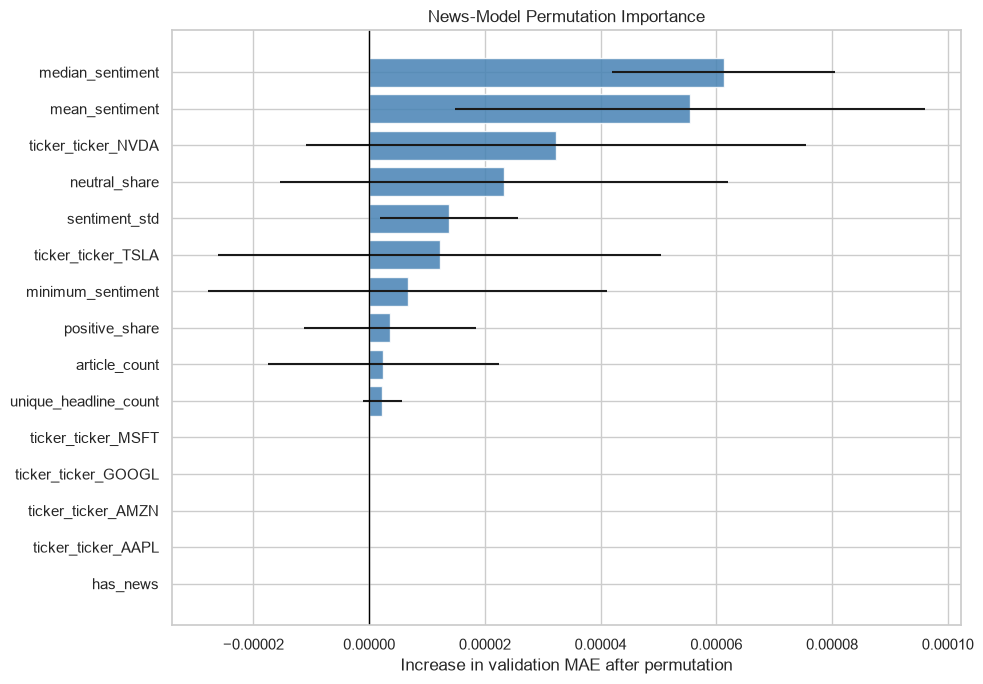

In [61]:
top_importance = (
    news_importance
    .head(15)
    .sort_values("importance_mean")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    color="steelblue",
    alpha=0.85,
)

ax.axvline(0, color="black", linewidth=1)

ax.set(
    title="News-Model Permutation Importance",
    xlabel="Increase in validation MAE after permutation",
    ylabel="",
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "news_permutation_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Test performance by ticker

In [62]:
ticker_test_data = combined_test.copy()

ticker_test_data["news_prediction"] = (
    news_only_experiment["predictions"]["test"]
)

ticker_test_data["global_mean_prediction"] = (
    global_mean_return
)

ticker_test_data["ticker_mean_prediction"] = (
    ticker_test_data["ticker"]
    .map(ticker_mean_returns)
)

In [63]:
ticker_model_results = []

prediction_columns = {
    "Global historical mean": "global_mean_prediction",
    "Ticker historical mean": "ticker_mean_prediction",
    "XGBoost: news only": "news_prediction",
}

for ticker, ticker_data in ticker_test_data.groupby(
    "ticker"
):
    for model_name, prediction_column in (
        prediction_columns.items()
    ):
        results = evaluate_constant_predictions(
            ticker_data,
            ticker_data[prediction_column].to_numpy(),
            model_name,
            "test",
        )

        ticker_model_results.append(
            {
                "ticker": ticker,
                **results,
            }
        )

ticker_model_results = pd.DataFrame(
    ticker_model_results
)

display(
    ticker_model_results[
        [
            "ticker",
            "model",
            "price_mae",
            "return_mae",
            "return_rmse",
            "direction_accuracy",
        ]
    ]
    .sort_values(["ticker", "return_mae"])
    .style.format(
        {
            "price_mae": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,ticker,model,price_mae,return_mae,return_rmse,direction_accuracy
0,AAPL,Global historical mean,$2.285,1.005%,1.388%,57.58%
1,AAPL,Ticker historical mean,$2.292,1.009%,1.389%,57.58%
2,AAPL,XGBoost: news only,$2.306,1.015%,1.399%,60.61%
4,AMZN,Ticker historical mean,$1.765,0.944%,1.197%,57.58%
3,AMZN,Global historical mean,$1.769,0.946%,1.201%,57.58%
5,AMZN,XGBoost: news only,$1.772,0.948%,1.211%,57.58%
8,GOOGL,XGBoost: news only,$1.254,0.773%,0.987%,69.70%
6,GOOGL,Global historical mean,$1.281,0.789%,1.013%,69.70%
7,GOOGL,Ticker historical mean,$1.292,0.797%,1.016%,69.70%
10,META,Ticker historical mean,$5.548,0.979%,1.322%,60.61%


In [65]:
ticker_return_mae = (
    ticker_model_results
    .pivot(
        index="ticker",
        columns="model",
        values="return_mae",
    )
)

display(
    ticker_return_mae.style.format("{:.3%}")
)

model,Global historical mean,Ticker historical mean,XGBoost: news only
ticker,,,
AAPL,1.005%,1.009%,1.015%
AMZN,0.946%,0.944%,0.948%
GOOGL,0.789%,0.797%,0.773%
META,0.983%,0.979%,0.998%
MSFT,0.722%,0.708%,0.731%
NVDA,1.812%,1.783%,1.816%
TSLA,2.612%,2.607%,2.642%


## News-feature interpretation

Permutation importance identifies median and mean daily sentiment as the most
useful news variables. Median sentiment has the strongest and most consistent
effect, suggesting that the central tone of a day's coverage is more informative
than individual extreme articles.

Sentiment dispersion and the neutral-news share provide smaller contributions.
By contrast, article count, unique headline count, and the binary indicator for
whether news was available have approximately zero importance. News quantity
alone therefore does not appear predictive; the tone of coverage carries more
information than its volume.

The absolute importance values remain small. Permuting median sentiment
increases validation return MAE by only approximately 0.006 percentage points.
Furthermore, several importance estimates have standard deviations comparable
to their means, indicating instability across permutations. Feature importance
should therefore be interpreted as descriptive rather than causal evidence.

### Performance by ticker

News-only XGBoost improves test return MAE only for Google, reducing error from
0.789% under the global historical-mean baseline to 0.773%. This suggests that
Google's news coverage contained useful signal during the test period.

For the other six stocks, news produces slightly higher errors than at least one
historical-mean baseline. The largest forecasting errors occur for Tesla and
NVIDIA, consistent with their substantially higher return volatility.

The lack of consistent improvement across tickers helps explain why the
news-only model performs well on validation but fails to outperform historical
drift on the aggregate test set.

In [66]:
news_availability_results = []

for has_news, subset in ticker_test_data.groupby(
    "has_news"
):
    label = (
        "Days with news"
        if has_news == 1
        else "Days without news"
    )

    for model_name, prediction_column in {
        "Global historical mean": "global_mean_prediction",
        "XGBoost: news only": "news_prediction",
    }.items():
        result = evaluate_constant_predictions(
            subset,
            subset[prediction_column].to_numpy(),
            model_name,
            "test",
        )

        news_availability_results.append(
            {
                "news_availability": label,
                "observations": len(subset),
                **result,
            }
        )

news_availability_results = pd.DataFrame(
    news_availability_results
)

display(
    news_availability_results[
        [
            "news_availability",
            "observations",
            "model",
            "return_mae",
            "return_rmse",
            "direction_accuracy",
        ]
    ].style.format(
        {
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        }
    )
)

,news_availability,observations,model,return_mae,return_rmse,direction_accuracy
0,Days without news,39,Global historical mean,0.940%,1.371%,71.79%
1,Days without news,39,XGBoost: news only,0.932%,1.364%,71.79%
2,Days with news,192,Global historical mean,1.334%,2.350%,55.21%
3,Days with news,192,XGBoost: news only,1.344%,2.365%,55.21%


### News versus no-news days

Test-period forecasting errors are substantially higher on days with news.
Under the global historical-mean baseline, return MAE increases from 0.940% on
no-news days to 1.334% on news days.

This does not imply that news causes volatility, because news publication is
not randomly assigned. News providers are more likely to publish articles when
companies experience important announcements, controversy, earnings releases,
or unusual market activity.

The news-only model does not improve predictions on active-news days. Its return
MAE of 1.344% is slightly worse than the global-mean baseline's 1.334%. On
no-news days, it produces a small improvement despite receiving zero-valued
news features, likely because of ticker indicators and learned default behavior.

Directional accuracy is identical between the models in both groups. Overall,
the model does not demonstrate that sentiment reliably converts company news
into next-day directional forecasts.

## Final model selection

The news-only XGBoost model was selected during model development because it
produced the strongest validation-period results. It achieved a validation
return MAE of 1.925%, compared with 1.937% for the global historical-mean
baseline.

On the untouched test period, however, the improvement did not persist. The
ticker-specific historical-mean baseline achieved the strongest final results:

- Price MAE: $3.184
- Price RMSE: $5.447
- Return MAE: 1.261%
- Return RMSE: 2.214%
- Directional accuracy: 58.01%

The news-only XGBoost model achieved:

- Price MAE: $3.229
- Price RMSE: $5.491
- Return MAE: 1.275%
- Return RMSE: 2.227%
- Directional accuracy: 58.01%

Its directional accuracy equals the positive-return base rate and therefore
does not represent meaningful classification skill.

For this dataset, the ticker-specific historical-mean forecast is the preferred
final benchmark because it is simpler, more stable, and slightly more accurate
on unseen test data. The news-only model remains an informative experimental
candidate, but its validation advantage is regime-dependent and insufficiently
stable for deployment.

The central finding is not that complex models cannot forecast markets under
all conditions. Rather, within this limited one-year sample, none of the tested
price, time-series, sentiment, or ensemble approaches consistently improves on
a carefully constructed historical-drift baseline.

Limitations

## Limitations

1. **Limited history:** Each ticker contains only 241 trading sessions. This
   covers approximately one year and does not represent multiple economic or
   interest-rate regimes.

2. **Small and concentrated universe:** The dataset contains seven large
   technology-oriented companies whose returns are positively correlated.
   Results may not generalize to other industries or smaller companies.

3. **Timestamp ambiguity:** The timezone of news publication timestamps is not
   documented. Articles were conservatively assigned to the next trading
   session to prevent leakage, potentially delaying usable information.

4. **Uneven news coverage:** Article counts differ substantially by ticker.
   News availability may reflect provider coverage decisions as well as genuine
   market importance.

5. **Repeated and syndicated content:** Exact duplicates were removed, but
   repeated headlines and summaries were retained when they appeared at
   different times. Some events may therefore receive disproportionate weight.

6. **Sentiment-model limitations:** FinBERT provides domain-appropriate
   sentiment features but was not calibrated specifically to these sources,
   tickers, or the prediction horizon.

7. **Missing market context:** The supplied data does not include broad-market
   indices, sector returns, volatility indices, interest rates, earnings
   calendars, or macroeconomic announcements.

8. **Single final test period:** Chronological validation protects temporal
   ordering, but a longer dataset would support multiple expanding-window folds
   and more reliable estimates of performance stability.

9. **No investment claim:** Predictive errors and directional accuracy do not
   account for transaction costs, liquidity, slippage, position sizing, or
   risk. The results should not be interpreted as evidence of a profitable
   trading strategy.